In [40]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# The three supplied supervised algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
RANDOM_STATE = 42

In [41]:
df = pd.read_csv("Booking.csv")

## 1. Exploratory Data Analysis

In [42]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [43]:
df.dtypes

Booking_ID                      str
number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                    str
car parking space             int64
room type                       str
lead time                     int64
market segment type             str
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation             str
booking status                  str
dtype: object

In [44]:
print("Shape:", df.shape)

Shape: (36285, 17)


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isna().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [47]:
df.drop(columns=["Booking_ID"], inplace=True)

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number of adults,36285.0,1.844839,0.518813,0.0,2.0,2.00,2.0,4.0
number of children,36285.0,0.105360,0.402704,0.0,0.0,0.00,0.0,10.0
number of weekend nights,36285.0,0.810693,0.870590,0.0,0.0,1.00,2.0,7.0
number of week nights,36285.0,2.204602,1.410946,0.0,1.0,2.00,3.0,17.0
car parking space,36285.0,0.030977,0.173258,0.0,0.0,0.00,0.0,1.0
lead time,36285.0,85.239851,85.938796,0.0,17.0,57.00,126.0,443.0
repeated,36285.0,0.025630,0.158032,0.0,0.0,0.00,0.0,1.0
P-C,36285.0,0.023343,0.368281,0.0,0.0,0.00,0.0,13.0
P-not-C,36285.0,0.153369,1.753931,0.0,0.0,0.00,0.0,58.0
average price,36285.0,103.421636,35.086469,0.0,80.3,99.45,120.0,540.0


C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_19072\3479799408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="booking status", palette="viridis")


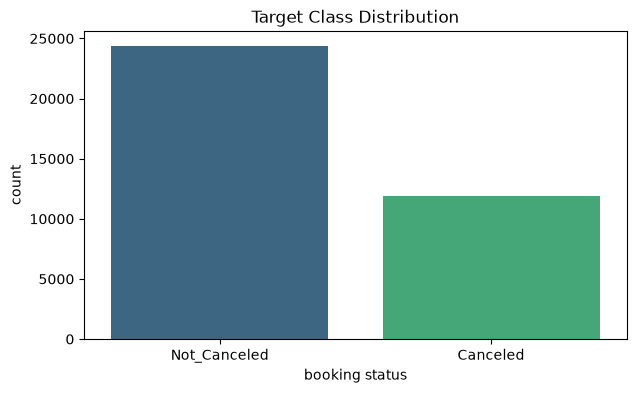

In [49]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="booking status", palette="viridis")
plt.title("Target Class Distribution")
plt.show()

In [50]:
df.dtypes

number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                    str
car parking space             int64
room type                       str
lead time                     int64
market segment type             str
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation             str
booking status                  str
dtype: object

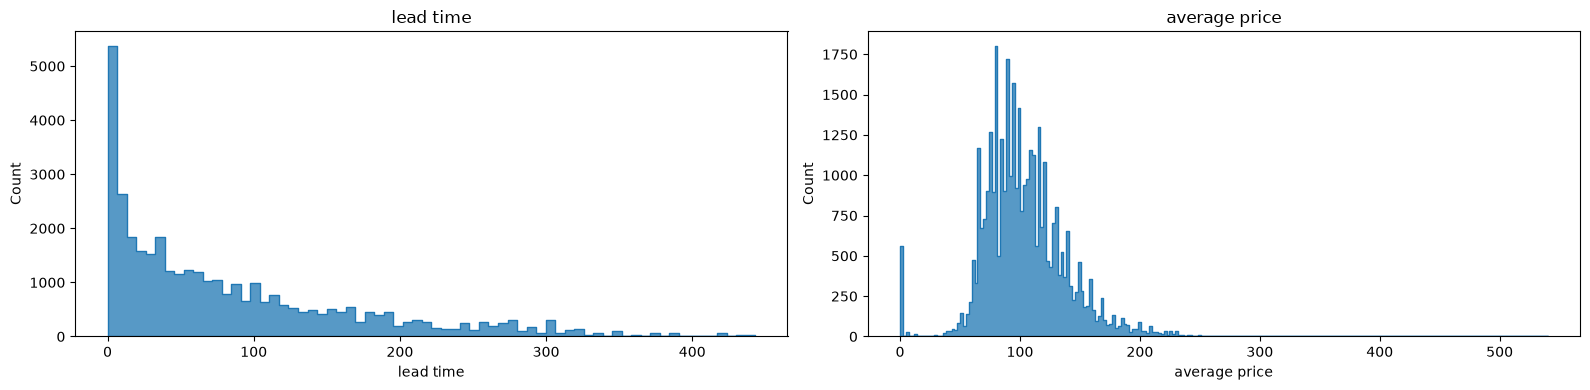

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, column in zip(axes, ["lead time", "average price"]):
    sns.histplot(data=df, x=column, element="step", ax=ax)
    ax.set_title(column)
plt.tight_layout(); plt.show()

C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_19072\286382408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="booking status", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_19072\286382408.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["NO", "Yes"])
C:\Users\AM BUSINESS 99\AppData\Local\Temp\ipykernel_19072\286382408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="booking status", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
C:\Users\AM BUSINESS 99

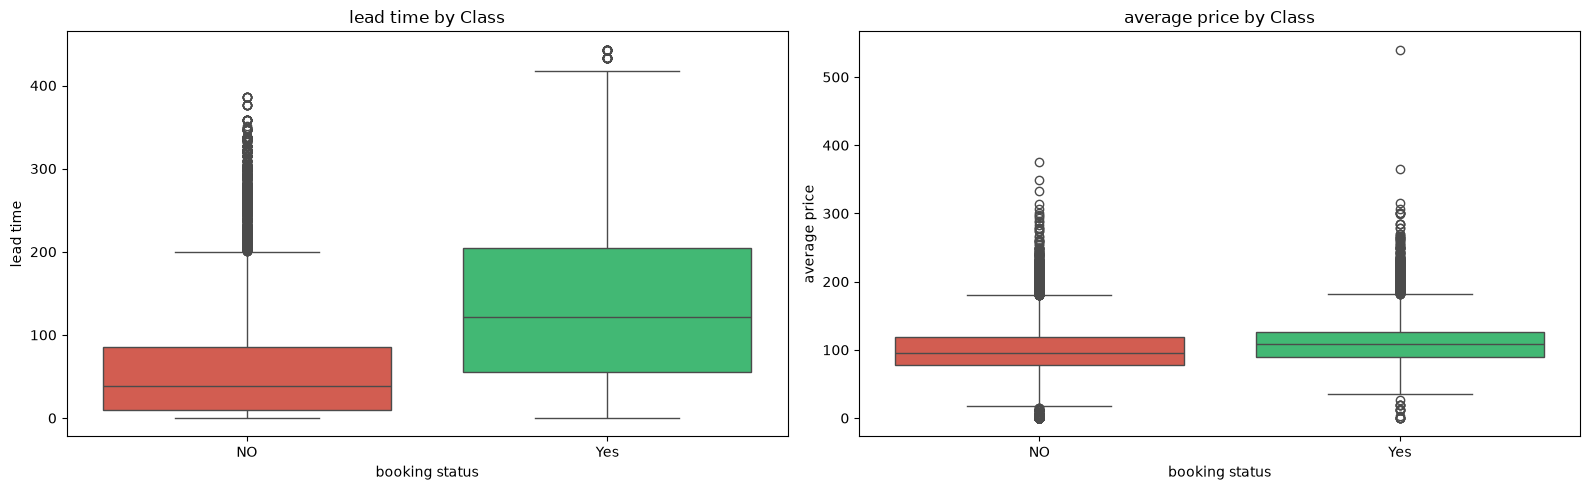

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, feature in zip(axes, ["lead time", "average price"]):
    sns.boxplot(x="booking status", y=feature, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_xticklabels(["NO", "Yes"])
    ax.set_title(f"{feature} by Class")

plt.tight_layout()
plt.show()

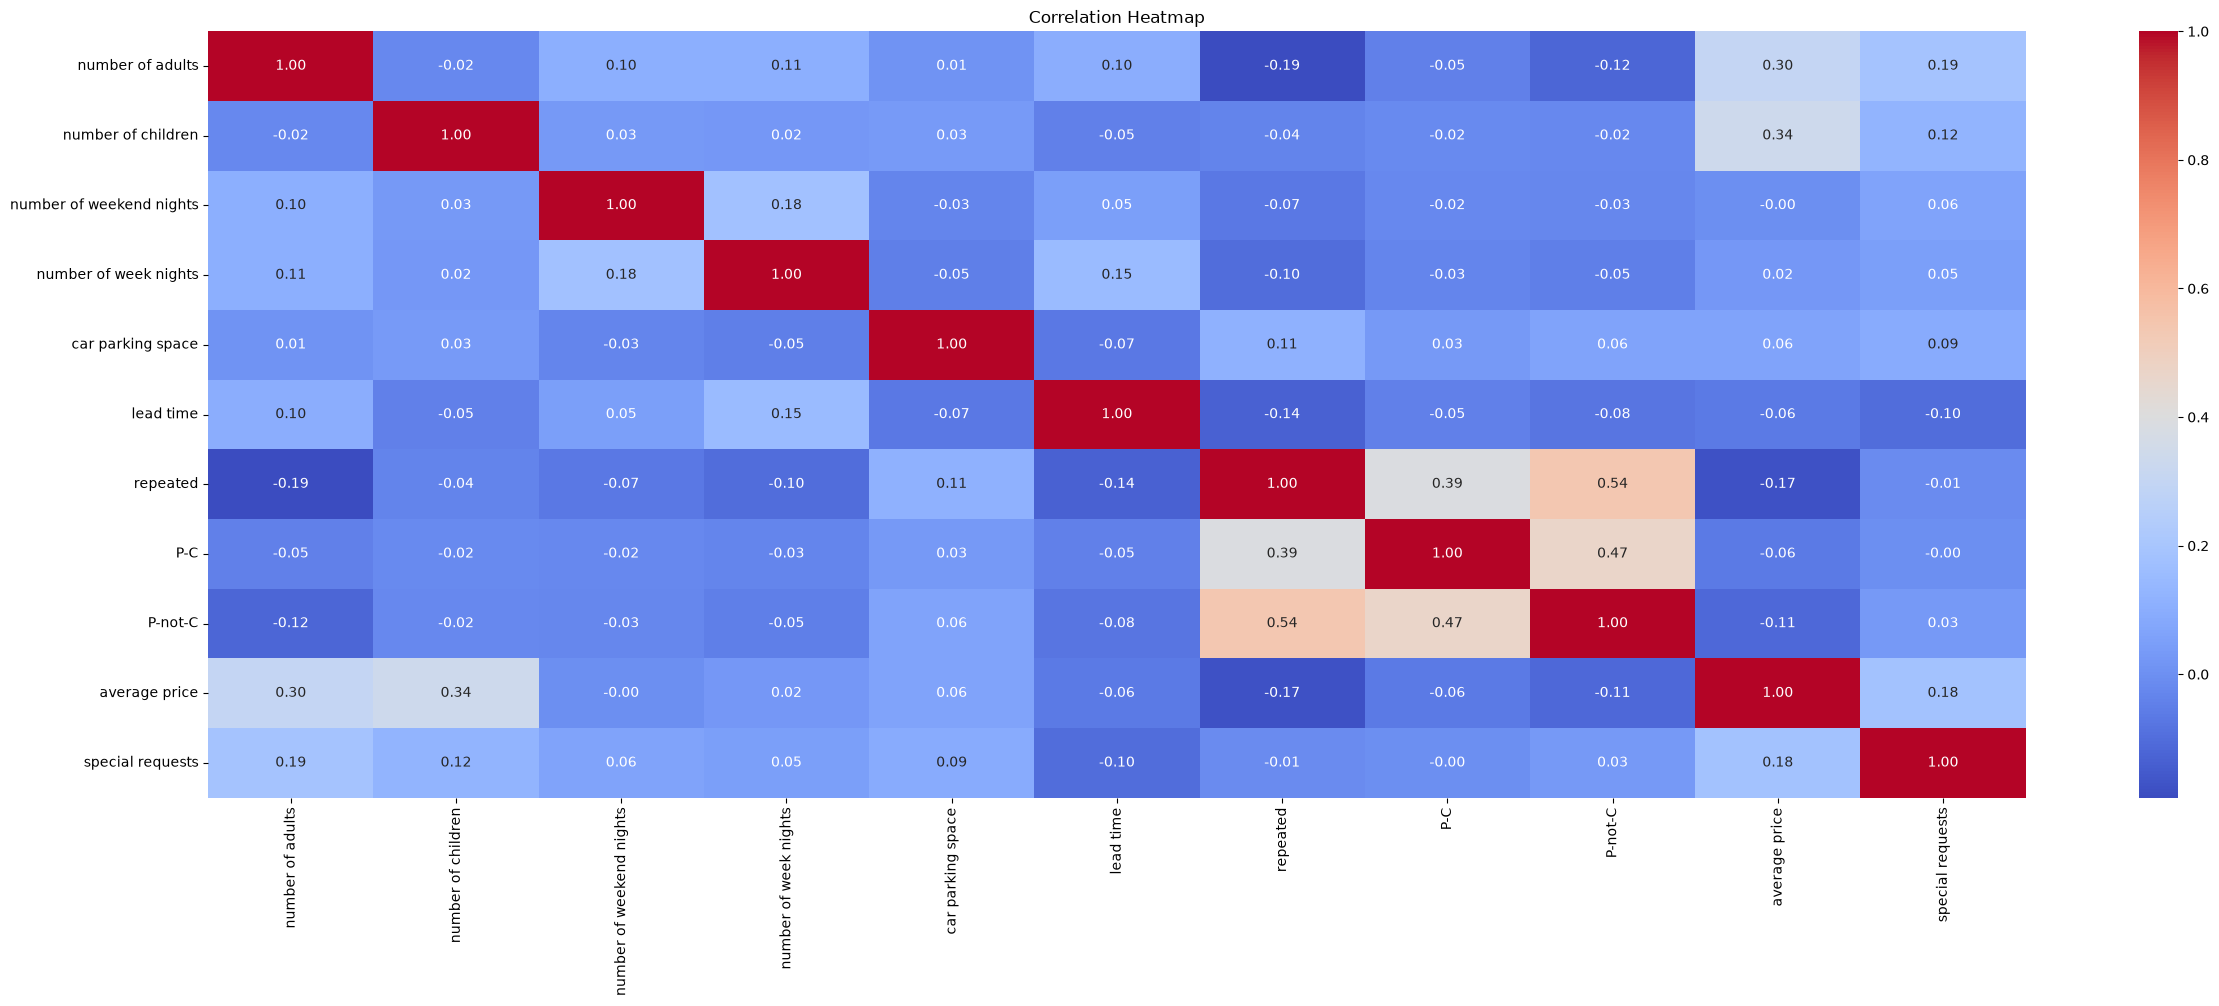

In [53]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[numerical_features].corr(numeric_only=True)

plt.figure(figsize=(25, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt='.2f')
plt.tight_layout()
plt.title("Correlation Heatmap")
plt.show()

In [54]:
le = LabelEncoder()
le.fit(df["booking status"])

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](2,)","['Canceled','Not_Canceled']"


In [55]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = df[numerical_features].apply(count_outliers_iqr).sort_values(ascending=False)
print("Top 10 features by outlier count:")
outlier_summary.head(10)

Top 10 features by outlier count:


number of adults         10175
number of children        2702
average price             1696
lead time                 1332
car parking space         1124
repeated                   930
P-not-C                    812
special requests           762
P-C                        338
number of week nights      324
dtype: int64

## 2. Train-Test Split Before Preprocessing

In [56]:
X = df.drop(columns=["booking status", "date of reservation"])
y = (df["booking status"] == "Canceled").astype(int).to_numpy()
print("Target mapping: {'Not_Canceled': 0, 'Canceled': 1}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train class proportions:", pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict())

Target mapping: {'Not_Canceled': 0, 'Canceled': 1}
Train class proportions: {0: 0.6724, 1: 0.3276}


## 3. Missing Values, One-Hot Encoding and Standardization

In [57]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Numeric missing values: training medians only.
train_medians = X_train[numeric_columns].median()
X_train_num = X_train[numeric_columns].fillna(train_medians)
X_test_num = X_test[numeric_columns].fillna(train_medians)

# Nominal categories: training modes followed by supplied OneHotEncoder.

train_modes = X_train[categorical_columns].mode().iloc[0]
X_train_cat = X_train[categorical_columns].fillna(train_modes)
X_test_cat = X_test[categorical_columns].fillna(train_modes)
onehot_encoder = OneHotEncoder()
X_train_cat_encoded = onehot_encoder.fit_transform(X_train_cat)
X_test_cat_encoded = onehot_encoder.transform(X_test_cat)

In [59]:
# Supplied StandardScaler; fitted only on training numeric values.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

X_train_processed = np.hstack([X_train_scaled, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_scaled, X_test_cat_encoded])

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

## Cross Validation, Regularization, Tuning and Three Models

In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_model = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
baseline_scores = cross_val_score(
    baseline_model, X_train_scaled, y_train,
    cv=cv_strategy, scoring="f1"
)
print("Baseline Logistic Regression fold F1 scores:", np.round(baseline_scores, 4))
print("Mean CV F1:", round(baseline_scores.mean(), 4),
      "| Standard deviation:", round(baseline_scores.std(), 4))

Baseline Logistic Regression fold F1 scores: [0.5944 0.6017 0.6262 0.619  0.6285]
Mean CV F1: 0.614 | Standard deviation: 0.0136


In [ ]:
regularization_results = []
for penalty in ["l1", "l2"]:
    model = LogisticRegression(
        penalty=penalty, solver="liblinear", C=1.0,
        max_iter=10000, random_state=RANDOM_STATE
    )
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv_strategy, scoring="f1")
    regularization_results.append({
        "Penalty": penalty.upper(),
        "Mean CV F1": scores.mean(),
        "CV F1 Std": scores.std()
    })
print(pd.DataFrame(regularization_results).round(4))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

  Penalty  Mean CV F1  CV F1 Std
0      L1      0.6138     0.0137
1      L2      0.6138     0.0137


In [ ]:
param_grid = {
    "C": [0.001, 0.01,0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [ ]:
grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1"
)
grid_search.fit(X_train_scaled, y_train)
print("Best Logistic Regression parameters:", grid_search.best_params_)
print("Best Logistic Regression CV F1:", round(grid_search.best_score_))

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

Best Logistic Regression parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression CV F1: 1


In [ ]:
SVM_TRAIN_LIMIT = 25000
X_svm_train, _, y_svm_train, _ = train_test_split(
X_train_processed, y_train, train_size=SVM_TRAIN_LIMIT,
random_state=RANDOM_STATE, stratify=y_train
)
print("SVM training rows:", len(X_svm_train))

SVM training rows: 25000


In [ ]:
models = {
    "Logistic Regression": grid_search.best_estimator_,
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
    "SVM (RBF Kernel)": SVC(
        kernel="rbf", probability=True, random_state=RANDOM_STATE
    )
}

In [ ]:
trained_models = {}
train_f1 = {}
for name, model in models.items():
    model.fit(X_svm_train, y_svm_train)
    train_prediction = model.predict(X_svm_train)
    train_f1[name] = f1_score(y_svm_train, train_prediction)

    trained_models[name] = model
    print(name, "trained successfully.")

c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression trained successfully.
Random Forest trained successfully.


c:\Users\AM BUSINESS 99\Desktop\work\env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM (RBF Kernel) trained successfully.


## 5. Model Evaluation

In [ ]:
eval_rows = []
predictions = {}
probabilities = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba
    test_f1 = f1_score(y_test, y_pred)
    eval_rows.append({
        "Model": name,
        "Train F1": train_f1[name],
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": test_f1,
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
    })

eval_df = pd.DataFrame(eval_rows).set_index("Model")
eval_df

,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,
Logistic Regression,0.667423,0.810390,0.759049,0.617325,0.680891,0.870111
Random Forest,0.987736,0.889073,0.856043,0.795206,0.824504,0.943044
SVM (RBF Kernel),0.710138,0.838225,0.828244,0.638772,0.721273,0.893502


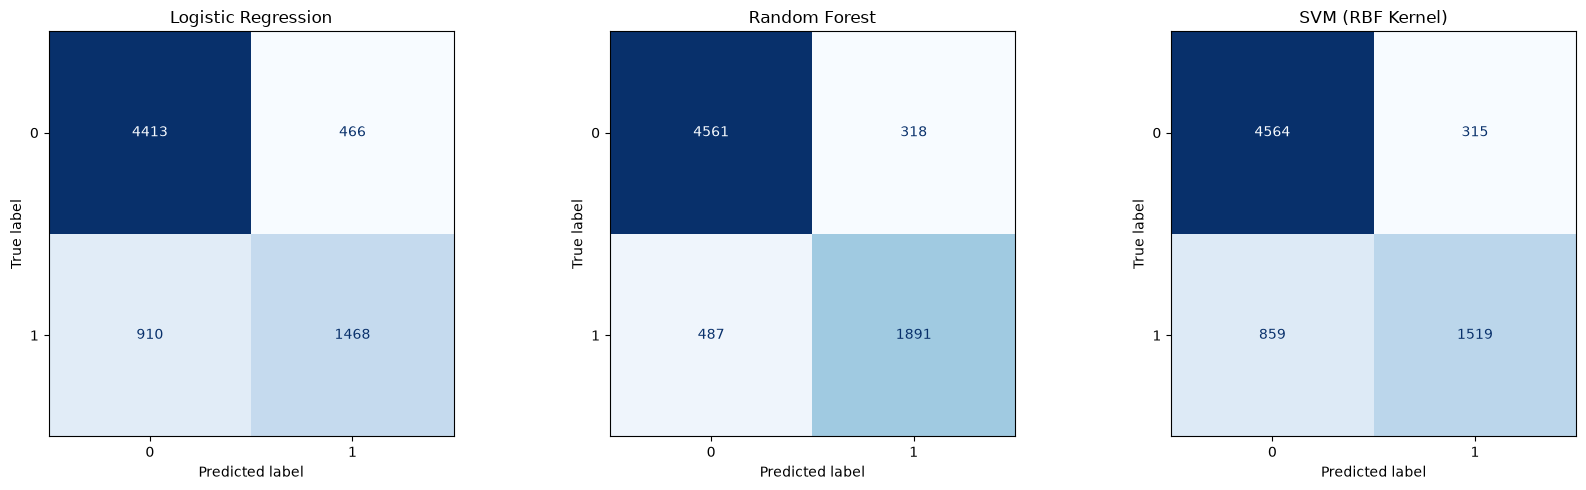

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

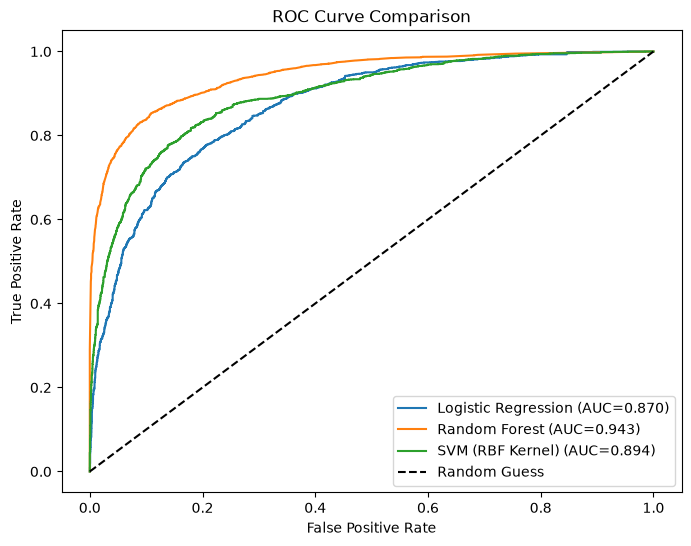

In [ ]:
plt.figure(figsize=(8, 6))
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
best_model_name = eval_df["Test F1"].idxmax()
print("Best model by Test F1:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, predictions[best_model_name]))

Best model by Test F1: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      4879
           1       0.86      0.80      0.82      2378

    accuracy                           0.89      7257
   macro avg       0.88      0.87      0.87      7257
weighted avg       0.89      0.89      0.89      7257



## 6. Final Model and Overfit/Underfit Check

In [ ]:
best_row = eval_df.loc[best_model_name]
print("Final selected model:", best_model_name)
print(best_row.round(4).to_string())

Final selected model: Random Forest
Train F1          0.9877
Test Accuracy     0.8891
Test Precision    0.8560
Test Recall       0.7952
Test F1           0.8245
Test ROC-AUC      0.9430
